# AvianNet
**Objective:** Evaluate performance of 3 models on classifying 5 species of North American birds using Mel-Spectrograms.

**AvianNet V1:**
* Custom 3-layer architecture

**AvianNet V2:**
* Transfer learning using ResNet18
* Feature extraction by freezing model weights

**AvianNet V3:**
* Fine-tuned transfer learning using ResNet18






**Data Notes:** 
* Dataset is filtered using RMS energy (either through mean or max RMS) to remove silent audio chunks (those lacking bird calls to predict off of).
* Moderate class imbalance was addressed using inverse frequency weighting in CrossEntropyLoss.
* Split was applied by unique recording ID to prevent data leakage across time-chunks.

**Blue Jay Mimicking:**
* The Blue Jay (Cyanocitta cristata) often mimics other birds in the wild, in particular, the Red-tailed hawks (Buteo jamaicensis) with high accuracy.
* Due to this, the model had some difficulty differentiating between Blue Jays and Red-tailed hawks.

In [14]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from pathlib import Path

from src.model import AvianNetModelV1, AvianNetModelV2
from src.dataset import get_dataloaders
from src.config_loader import load_config

In [15]:
def run_inference(model, file_name, model_name, data_folder):

    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
    model = model.to(device)

    model_path = Path.cwd() / 'models' / file_name
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    print("Model weights loaded")

    _, test_dataloader = get_dataloaders(data_folder=data_folder)
    all_preds = []
    all_true_labels = []
    print("Running inference on the test dataset.")

    loss_fn =  nn.CrossEntropyLoss().to(device)
    test_loss = 0

    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            X_test = X_test.to(device)
            y_test = y_test.to(device)
        
            
            
            # Convert logits to predicted class indices (0 through 4)
            logits = model(X_test)

            preds = logits.argmax(dim=1).cpu().numpy()
            true_labels = y_test.cpu().numpy()

            # Compute Loss
            test_loss += loss_fn(logits, y_test).item() * X_test.size(0)



            # Store for the confusion matrix
            all_preds.extend(preds)
            all_true_labels.extend(true_labels)

    test_loss = (test_loss / len(test_dataloader.dataset))
    print(f"Inference complete. Processed {len(all_preds)} audio chunks.")
    print(f"Test Loss: {test_loss:.4f}")

    # Create the confusion matrix
    cm= confusion_matrix(all_true_labels, all_preds)
    dataset_dict = test_dataloader.dataset.species_to_idx_dict
    bird_classes = [name for name, index in sorted(dataset_dict.items(), key=lambda x: x[1])]

    # Matrix Plotting
    plt.figure(figsize=(12, 9))
    sns.heatmap(cm, 
                annot=True,       
                fmt='d',     
                cmap='Blues',
                xticklabels=bird_classes, 
                yticklabels=bird_classes,
                annot_kws={"size": 12})

    plt.title(f'{model_name} Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Predicted Bird Species', fontsize=14, labelpad=15)
    plt.ylabel('Actual Bird Species', fontsize=14, labelpad=15)

    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(rotation=0, fontsize=11)

    plt.tight_layout()
    plt.show()

    report = classification_report(
        all_true_labels,
        all_preds,
        target_names=bird_classes
    )
    print(f"Classification Report - {model_name}")
    print("-" * 50)
    print(report)  

Model weights loaded
Running inference on the test dataset.
Inference complete. Processed 559 audio chunks.
Test Loss: 0.5927


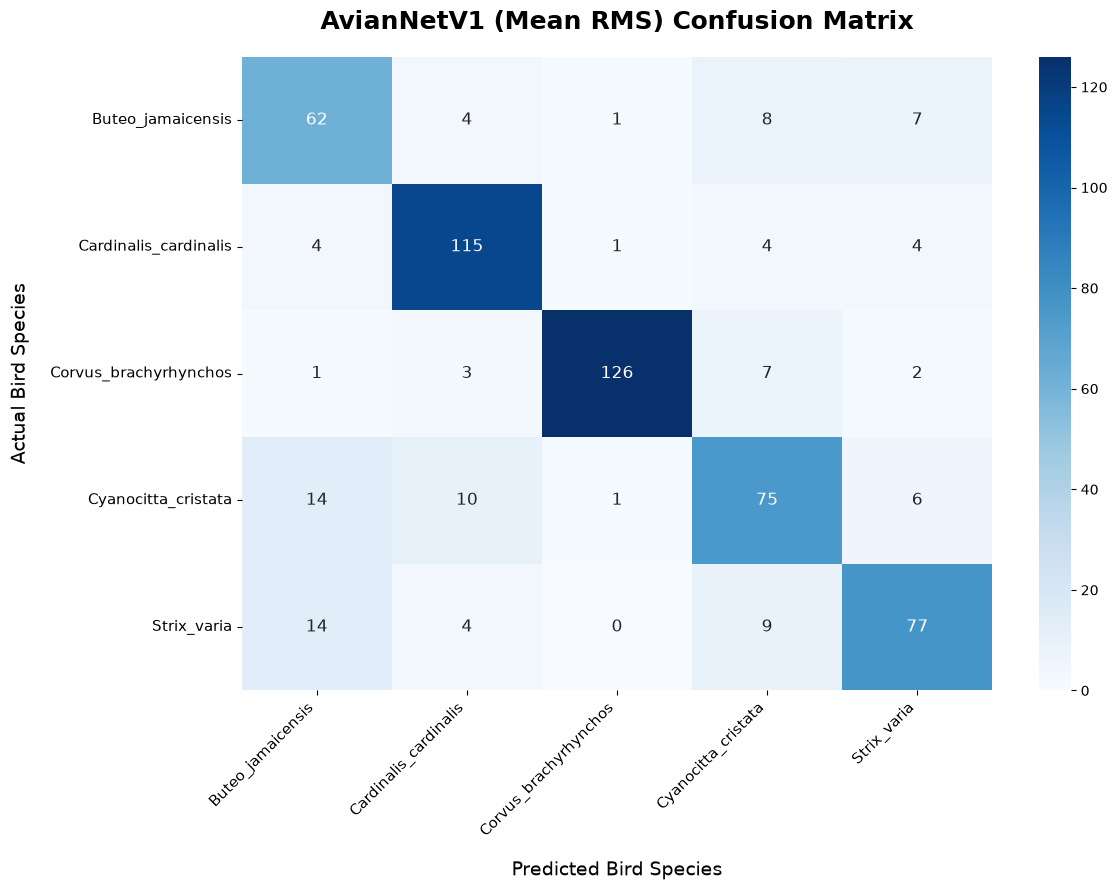

Classification Report - AvianNetV1 (Mean RMS)
--------------------------------------------------
                       precision    recall  f1-score   support

    Buteo_jamaicensis       0.65      0.76      0.70        82
Cardinalis_cardinalis       0.85      0.90      0.87       128
Corvus_brachyrhynchos       0.98      0.91      0.94       139
  Cyanocitta_cristata       0.73      0.71      0.72       106
          Strix_varia       0.80      0.74      0.77       104

             accuracy                           0.81       559
            macro avg       0.80      0.80      0.80       559
         weighted avg       0.82      0.81      0.82       559

__________________________________________________
Model weights loaded
Running inference on the test dataset.
Inference complete. Processed 713 audio chunks.
Test Loss: 0.9293


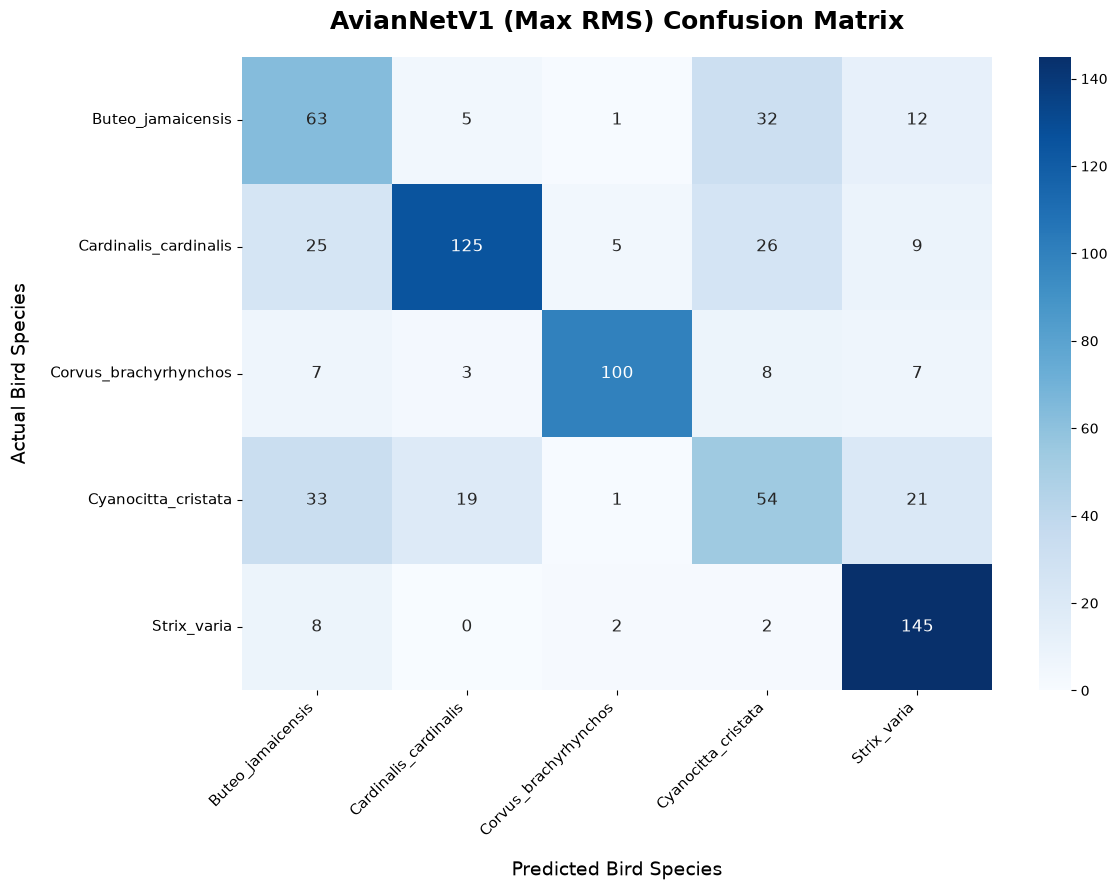

Classification Report - AvianNetV1 (Max RMS)
--------------------------------------------------
                       precision    recall  f1-score   support

    Buteo_jamaicensis       0.46      0.56      0.51       113
Cardinalis_cardinalis       0.82      0.66      0.73       190
Corvus_brachyrhynchos       0.92      0.80      0.85       125
  Cyanocitta_cristata       0.44      0.42      0.43       128
          Strix_varia       0.75      0.92      0.83       157

             accuracy                           0.68       713
            macro avg       0.68      0.67      0.67       713
         weighted avg       0.70      0.68      0.68       713



In [16]:
run_inference(
    model=AvianNetModelV1(input_shape=3, hidden_units=32, output_shape=5), 
    file_name='avian_net_V1_mean.pth', 
    model_name='AvianNetV1 (Mean RMS)', 
    data_folder='processed_mean'
              )
print("_" * 50)
run_inference(
    model=AvianNetModelV1(input_shape=3, hidden_units=32, output_shape=5), 
    file_name='avian_net_v1.pth', 
    model_name='AvianNetV1 (Max RMS)', 
    data_folder='processed'
              )

Model weights loaded
Running inference on the test dataset.
Inference complete. Processed 559 audio chunks.
Test Loss: 0.3766


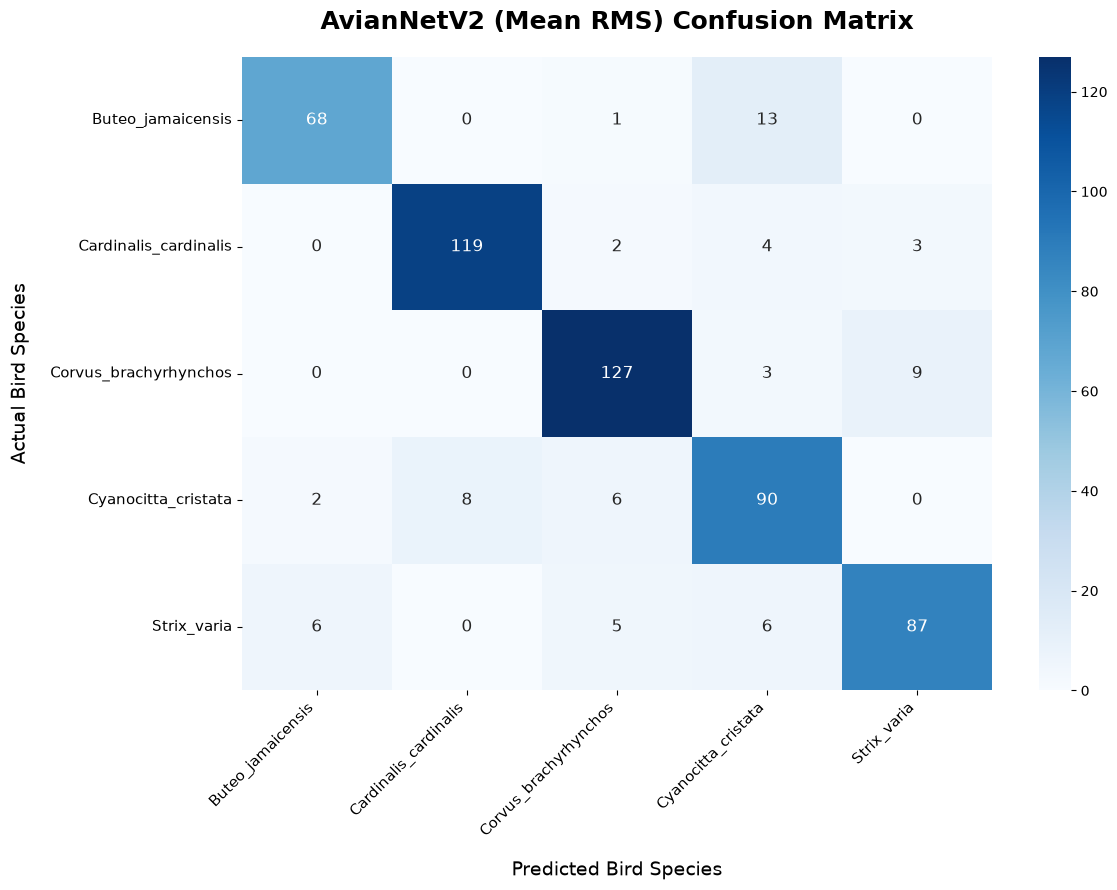

Classification Report - AvianNetV2 (Mean RMS)
--------------------------------------------------
                       precision    recall  f1-score   support

    Buteo_jamaicensis       0.89      0.83      0.86        82
Cardinalis_cardinalis       0.94      0.93      0.93       128
Corvus_brachyrhynchos       0.90      0.91      0.91       139
  Cyanocitta_cristata       0.78      0.85      0.81       106
          Strix_varia       0.88      0.84      0.86       104

             accuracy                           0.88       559
            macro avg       0.88      0.87      0.87       559
         weighted avg       0.88      0.88      0.88       559

__________________________________________________
Model weights loaded
Running inference on the test dataset.
Inference complete. Processed 713 audio chunks.
Test Loss: 0.6012


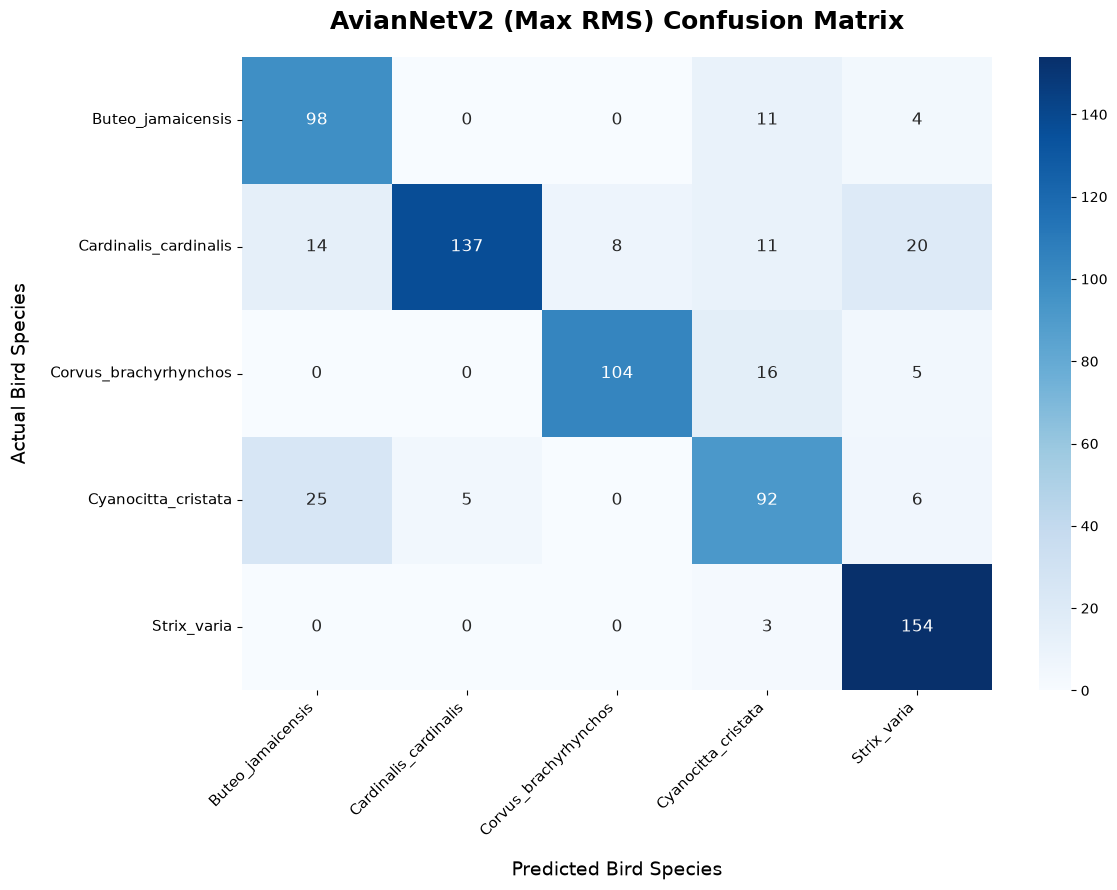

Classification Report - AvianNetV2 (Max RMS)
--------------------------------------------------
                       precision    recall  f1-score   support

    Buteo_jamaicensis       0.72      0.87      0.78       113
Cardinalis_cardinalis       0.96      0.72      0.83       190
Corvus_brachyrhynchos       0.93      0.83      0.88       125
  Cyanocitta_cristata       0.69      0.72      0.70       128
          Strix_varia       0.81      0.98      0.89       157

             accuracy                           0.82       713
            macro avg       0.82      0.82      0.82       713
         weighted avg       0.84      0.82      0.82       713



In [17]:
# LR = 0.001, weights frozen

run_inference(
    model=AvianNetModelV2(num_classes=5, freeze_weights=True), 
    file_name='avian_net_V2_mean.pth', 
    model_name='AvianNetV2 (Mean RMS)', 
    data_folder='processed_mean'
              )
print("_" * 50)
run_inference(
    model=AvianNetModelV2(num_classes=5, freeze_weights=True), 
    file_name='avian_net_v2.pth', 
    model_name='AvianNetV2 (Max RMS)', 
    data_folder='processed'
              )

Model weights loaded
Running inference on the test dataset.
Inference complete. Processed 559 audio chunks.
Test Loss: 0.3197


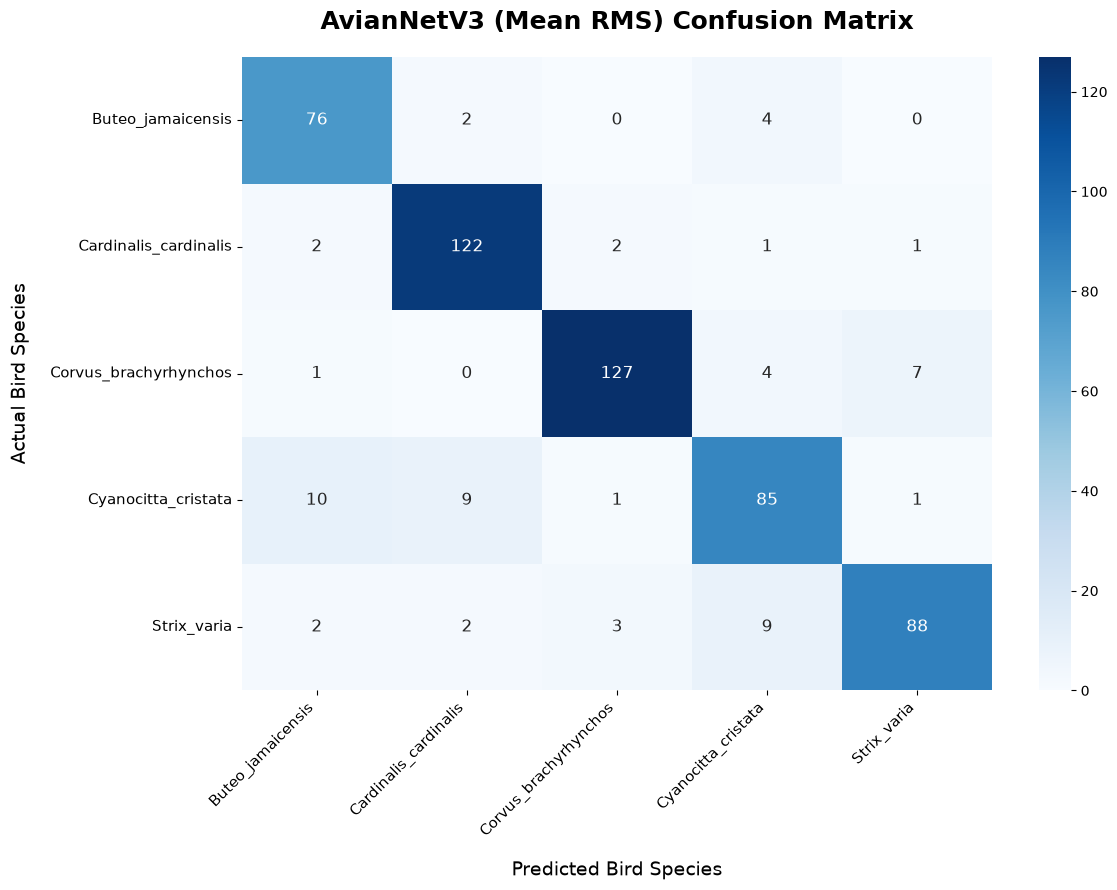

Classification Report - AvianNetV3 (Mean RMS)
--------------------------------------------------
                       precision    recall  f1-score   support

    Buteo_jamaicensis       0.84      0.93      0.88        82
Cardinalis_cardinalis       0.90      0.95      0.93       128
Corvus_brachyrhynchos       0.95      0.91      0.93       139
  Cyanocitta_cristata       0.83      0.80      0.81       106
          Strix_varia       0.91      0.85      0.88       104

             accuracy                           0.89       559
            macro avg       0.89      0.89      0.89       559
         weighted avg       0.89      0.89      0.89       559

__________________________________________________
Model weights loaded
Running inference on the test dataset.
Inference complete. Processed 713 audio chunks.
Test Loss: 0.5640


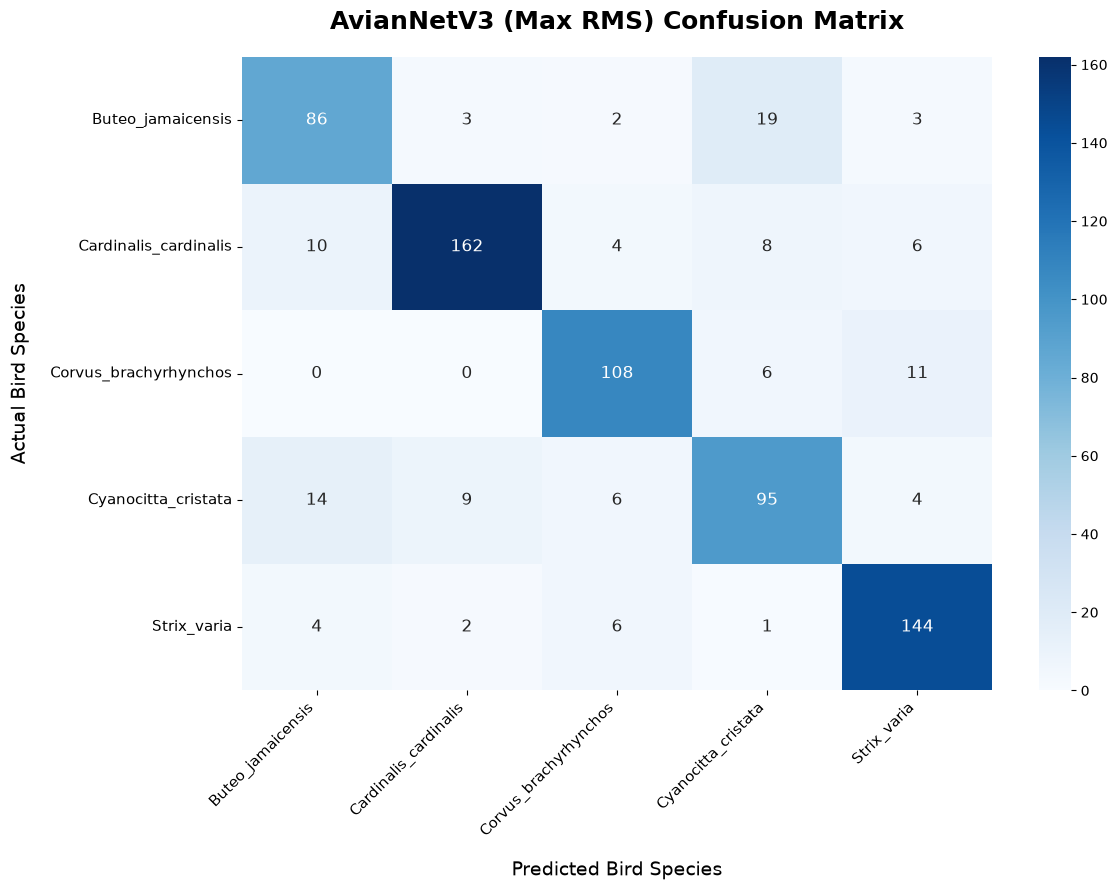

Classification Report - AvianNetV3 (Max RMS)
--------------------------------------------------
                       precision    recall  f1-score   support

    Buteo_jamaicensis       0.75      0.76      0.76       113
Cardinalis_cardinalis       0.92      0.85      0.89       190
Corvus_brachyrhynchos       0.86      0.86      0.86       125
  Cyanocitta_cristata       0.74      0.74      0.74       128
          Strix_varia       0.86      0.92      0.89       157

             accuracy                           0.83       713
            macro avg       0.83      0.83      0.83       713
         weighted avg       0.84      0.83      0.83       713

__________________________________________________
Model weights loaded
Running inference on the test dataset.
Inference complete. Processed 713 audio chunks.
Test Loss: 0.5598


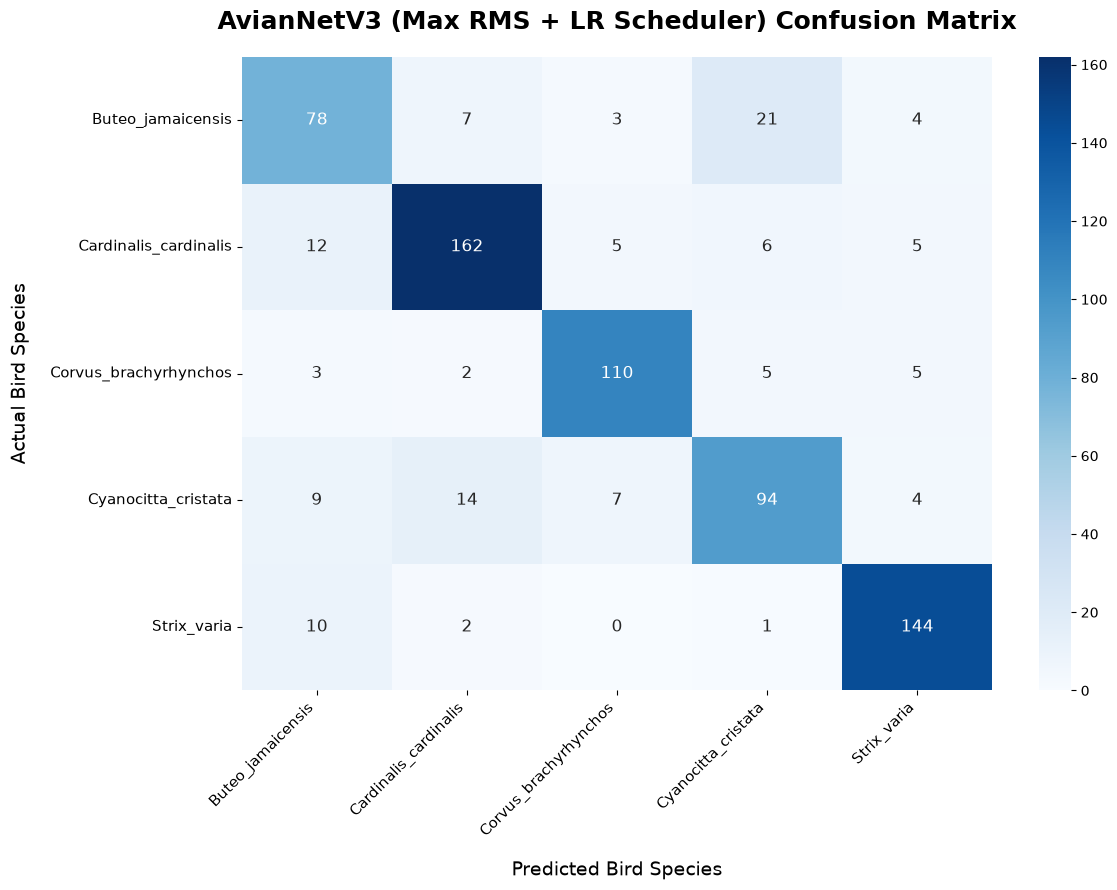

Classification Report - AvianNetV3 (Max RMS + LR Scheduler)
--------------------------------------------------
                       precision    recall  f1-score   support

    Buteo_jamaicensis       0.70      0.69      0.69       113
Cardinalis_cardinalis       0.87      0.85      0.86       190
Corvus_brachyrhynchos       0.88      0.88      0.88       125
  Cyanocitta_cristata       0.74      0.73      0.74       128
          Strix_varia       0.89      0.92      0.90       157

             accuracy                           0.82       713
            macro avg       0.81      0.81      0.81       713
         weighted avg       0.82      0.82      0.82       713



In [19]:
# LR = 0.0001, Weights frozen
run_inference(
    model=AvianNetModelV2(num_classes=5), 
    file_name='avian_net_V3_mean.pth', 
    model_name='AvianNetV3 (Mean RMS)', 
    data_folder='processed_mean'
              )

print("_" * 50)
run_inference(
    model=AvianNetModelV2(num_classes=5), 
    file_name='avian_net_v3.pth', 
    model_name='AvianNetV3 (Max RMS)', 
    data_folder='processed'
              )

print("_" * 50)
run_inference(
    model=AvianNetModelV2(num_classes=5), 
    file_name='avian_net_v3_loss_scheduler.pth', 
    model_name='AvianNetV3 (Max RMS + LR Scheduler)', 
    data_folder='processed'
              )

